In [82]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("EVDataExplorer2025.xlsx")
df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,_World
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,_World
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Other
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Other
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,_World


In [88]:
df_ev = df[df["parameter"] == "EV sales share"]

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
7561,Norway,Historical,EV sales share,Cars,EV,2024,percent,92.0,Other
7575,Norway,Historical,EV sales share,Cars,EV,2023,percent,90.0,Other
7587,Norway,Historical,EV sales share,Cars,EV,2022,percent,89.0,Other
7618,Norway,Historical,EV sales share,Cars,EV,2021,percent,86.0,Other
7657,China,Projection-STEPS,EV sales share,Cars,EV,2030,percent,82.0,Other


In [90]:
df_plot = df_real.groupby(["year", "region_country"])["value"].sum().reset_index()

In [76]:
df_real = df_ev[df_ev["year"] <= 2024]
df_plot = df_real.groupby(["year", "region_country"])["value"].sum().reset_index()
df_plot.head()

,year,region_country,value
0,2010,Asia Pacific,0.23980
1,2010,Belgium,0.02300
2,2010,Brazil,0.00035
3,2010,Canada,0.00110
4,2010,Central and South America,0.00266


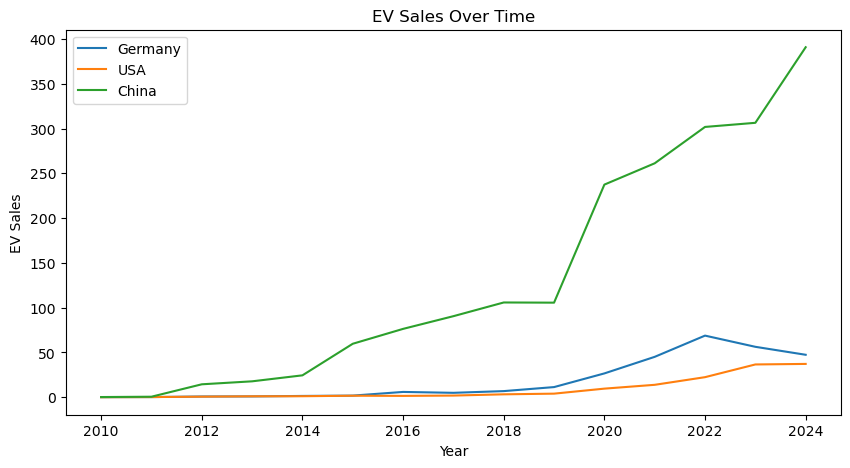

In [92]:
countries = ["Germany", "USA", "China"]

df_small = df_plot[df_plot["region_country"].isin(countries)]

plt.figure(figsize=(10,5))

for c in countries:
    data = df_small[df_small["region_country"] == c]
    plt.plot(data["year"], data["value"], label=c)

plt.title("EV Sales Over Time")
plt.xlabel("Year")
plt.ylabel("EV Sales")
plt.legend()
plt.show()

In [98]:
df_pivot = df_small.pivot(index="year", columns="region_country", values="value")

first_year = df_pivot.index.min()
last_year = df_pivot.index.max()

growth = df_pivot.loc[last_year] - df_pivot.loc[first_year]
growth.sort_values(ascending=False)

region_country
China      390.5903
Germany     47.3081
USA         37.1862
dtype: float64

In [32]:
# EV adoption increased across all regions, with China showing the strongest transformation. EV market share rose by approximately 390 percentage points in China, compared to 47 in Germany and 37 in the USA, indicating that China experienced a much earlier and more aggressive transition to electric mobility.